# Project Progress 1 — Data acquisition, preprocessing pl

## Data source (public, anonymized)

- **Dataset used here:** `Hemg/bone-fracture-detection` on Hugging Face (~8.8k X-ray images, 2 classes). This matches the proposal’s goal of a public fracture vs. non-fracture radiograph corpus aligned with sports medicine screening (even though body-part labels are not separated in this release).
- **Alternative (proposal text):** MURA or a Kaggle fracture dataset can be swapped in later milestones using the same preprocessing and EDA template.




In [2]:
# Colab: install dependencies (safe to re-run). Comment out if running locally with venv already set up.
import sys
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q datasets torch torchvision matplotlib pandas pillow tqdm

In [4]:
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
import torch
import torch.nn.functional as F
from datasets import load_dataset
from PIL import Image
from torchvision import transforms

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

IMG_SIZE = 224  # proposal: standardize to 224×224 for CNN compatibility

## 1) Load the dataset

We load the public Hugging Face split. The first download may take a few minutes depending on bandwidth.

In [5]:
# I load the Dataset

ds = load_dataset("Hemg/bone-fracture-detection")
train = ds["train"]
label_feature = train.features["label"]
class_names = list(label_feature.names)
print("Splits:", list(ds.keys()))
print("Num examples:", len(train))
print("Classes:", class_names)
print("Example keys:", train[0].keys())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/580 [00:00<?, ?B/s]

data/train-00000-of-00001-4c0dff0dab82a7(…):   0%|          | 0.00/165M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8863 [00:00<?, ? examples/s]

Splits: ['train']
Num examples: 8863
Classes: ['fractured', 'not fractured']
Example keys: dict_keys(['image', 'label'])


 2) Exploratory Data Analysis (EDA)

 2a) Class distribution (imbalance check)

,class,count,percent
0,fractured,4480,50.547219
1,not fractured,4383,49.452781


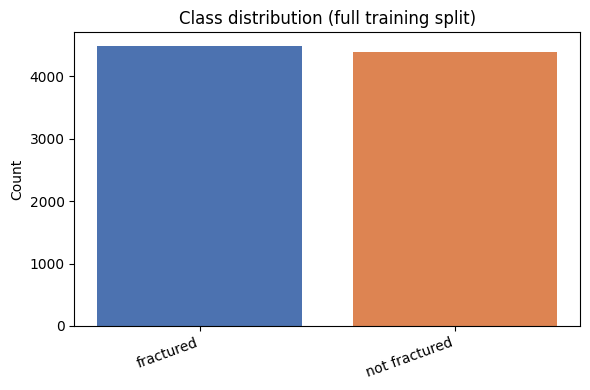

Majority/minority ratio ≈ 1.02


In [6]:
# Class distribution

labels = [int(x["label"]) for x in train]
counts = Counter(labels)
count_df = pd.DataFrame(
    {"class": [class_names[i] for i in sorted(counts.keys())], "count": [counts[i] for i in sorted(counts.keys())]}
)
count_df["percent"] = 100.0 * count_df["count"] / count_df["count"].sum()
display(count_df)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(count_df["class"], count_df["count"], color=["#4C72B0", "#DD8452"])
ax.set_title("Class distribution (full training split)")
ax.set_ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

imbalance_ratio = max(count_df["count"]) / min(count_df["count"])
print(f"Majority/minority ratio ≈ {imbalance_ratio:.2f}")


 2b) Pixel intensity histograms (grayscale)

We convert each image to 8-bit grayscale and subsample pixels for speed, stratified by label.

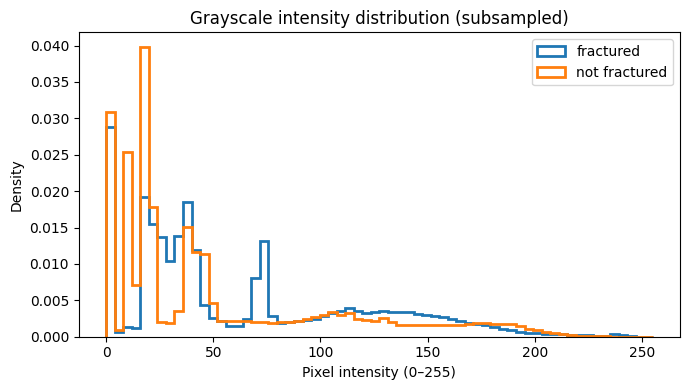

In [7]:
# Pixel historigram

def pil_image(ex):
    img = ex["image"]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(np.asarray(img))
    return img.convert("L")

rng = np.random.default_rng(RANDOM_SEED)
per_class = 250
sample_idx_by_label = {c: [] for c in range(len(class_names))}
for i, y in enumerate(labels):
    if len(sample_idx_by_label[y]) < per_class:
        sample_idx_by_label[y].append(i)

pixels_by_label = {c: [] for c in range(len(class_names))}
for c, idxs in sample_idx_by_label.items():
    for i in idxs:
        g = np.asarray(pil_image(train[i]), dtype=np.uint8)
        flat = g.reshape(-1)
        # subsample up to 30k pixels per image
        if flat.size > 30_000:
            flat = rng.choice(flat, size=30_000, replace=False)
        pixels_by_label[c].append(flat)
    pixels_by_label[c] = np.concatenate(pixels_by_label[c], axis=0)

fig, ax = plt.subplots(figsize=(7, 4))
for c in range(len(class_names)):
    ax.hist(
        pixels_by_label[c],
        bins=64,
        range=(0, 255),
        density=True,
        histtype="step",
        linewidth=2,
        label=class_names[c],
    )
ax.set_title("Grayscale intensity distribution (subsampled)")
ax.set_xlabel("Pixel intensity (0–255)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

2c) Sample grid (label sanity check)

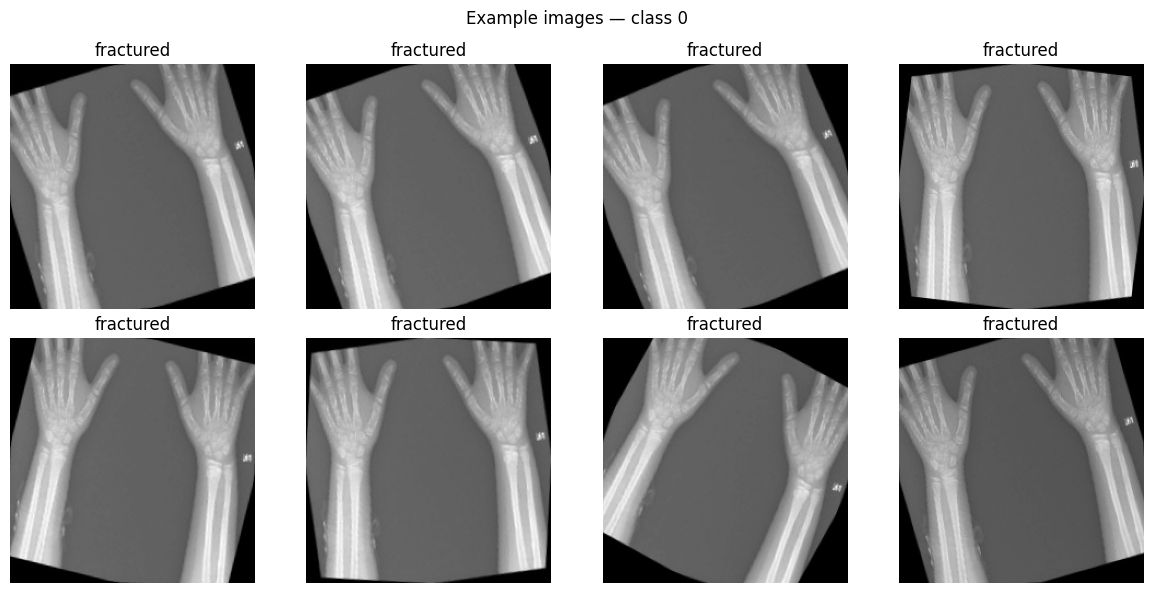

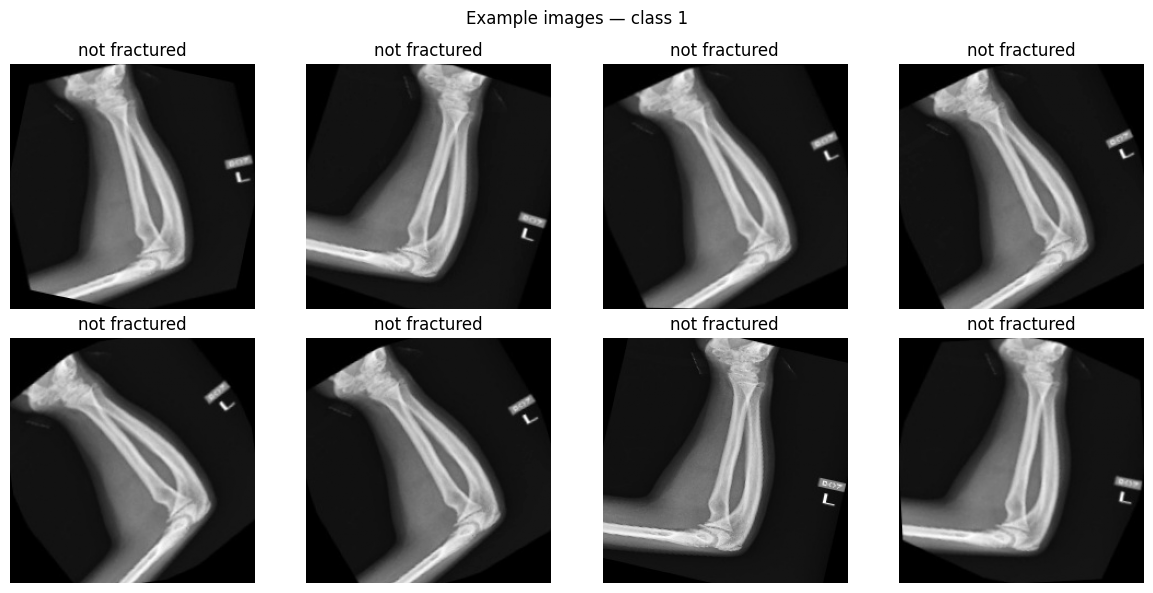

In [8]:
# Sample grid (Sanity check)

def show_grid(idxs, title):
    cols = 4
    rows = int(np.ceil(len(idxs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)
    for ax, i in zip(axes, idxs):
        ex = train[i]
        img = ex["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.asarray(img))
        ax.imshow(img.convert("L"), cmap="gray")
        ax.set_title(class_names[int(ex["label"])])
        ax.axis("off")
    for ax in axes[len(idxs) :]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

idxs0 = [i for i, y in enumerate(labels) if y == 0][:8]
idxs1 = [i for i, y in enumerate(labels) if y == 1][:8]
show_grid(idxs0, "Example images — class 0")
show_grid(idxs1, "Example images — class 1")



 3) Preprocessing & augmentation (training pipeline preview)

Per the proposal:

- **Resize** to `224×224` for CNN input uniformity.
- **Normalization:** `ToTensor()` maps pixels to **[0, 1]**; for transfer learning in Progress 2, we will switch to ImageNet mean/std normalization when using pretrained backbones.
- **Augmentation:** random rotation, horizontal flip, and brightness jitter to reduce overfitting and simulate acquisition variability.
- **Labels:** demonstrated below as **one-hot** vectors for softmax training.

## 3) Preprocessing & augmentation (training pipeline preview)

Per the proposal:

- **Resize** to `224×224` for CNN input uniformity.
- **Normalization:** `ToTensor()` maps pixels to **[0, 1]**; for transfer learning in Progress 2, we will switch to ImageNet mean/std normalization when using pretrained backbones.
- **Augmentation:** random rotation, horizontal flip, and brightness jitter to reduce overfitting and simulate acquisition variability.
- **Labels:** demonstrated below as **one-hot** vectors for softmax training.

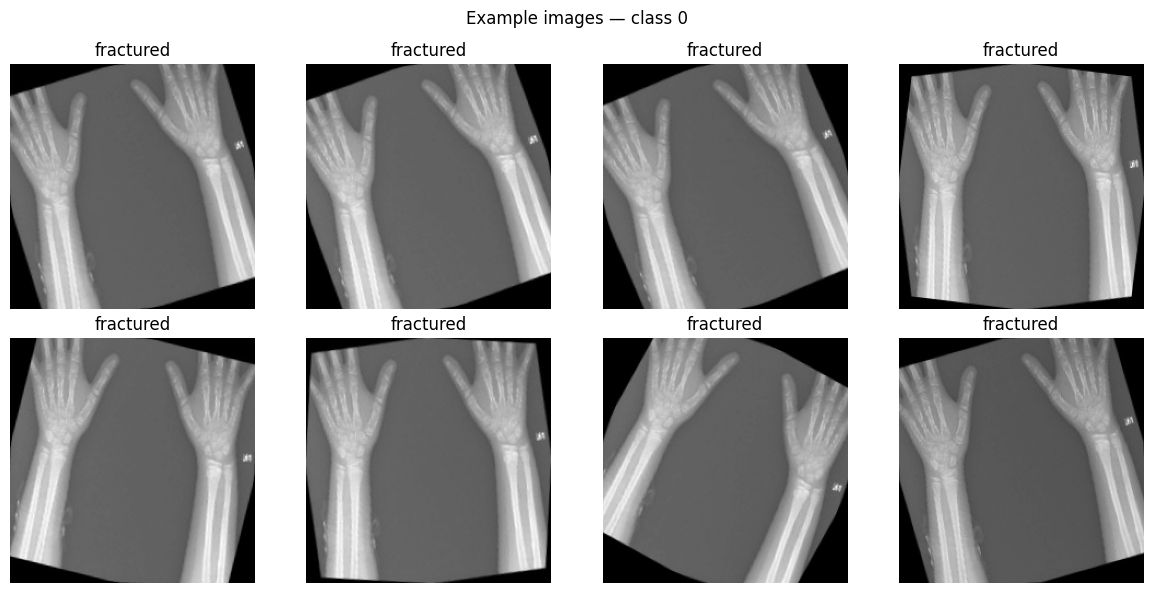

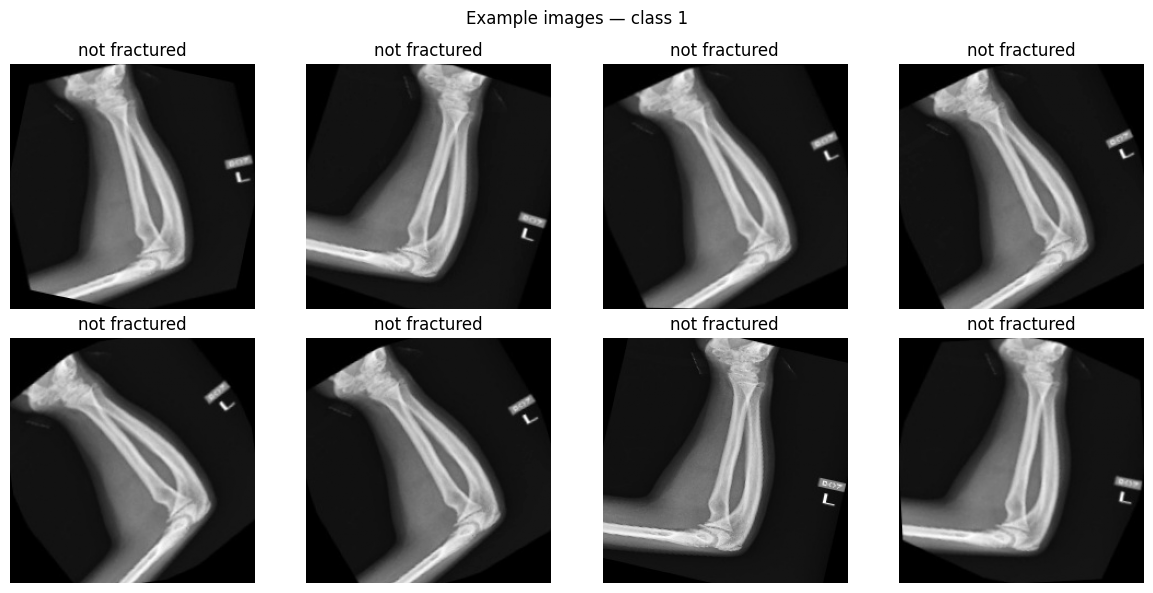

In [9]:
# Preprocessing and Augmentation

def show_grid(idxs, title):
    cols = 4
    rows = int(np.ceil(len(idxs) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = np.array(axes).reshape(-1)
    for ax, i in zip(axes, idxs):
        ex = train[i]
        img = ex["image"]
        if not isinstance(img, Image.Image):
            img = Image.fromarray(np.asarray(img))
        ax.imshow(img.convert("L"), cmap="gray")
        ax.set_title(class_names[int(ex["label"])])
        ax.axis("off")
    for ax in axes[len(idxs) :]:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

idxs0 = [i for i, y in enumerate(labels) if y == 0][:8]
idxs1 = [i for i, y in enumerate(labels) if y == 1][:8]
show_grid(idxs0, "Example images — class 0")
show_grid(idxs1, "Example images — class 1")

In [10]:
# Labels demonstrated below one hot vector for softmax

num_classes = len(class_names)
demo_labels = torch.tensor([0, 1, 1, 0], dtype=torch.long)
one_hot = F.one_hot(demo_labels, num_classes=num_classes).float()
print("Integer labels:", demo_labels.tolist())
print("One-hot encodings:\n", one_hot.numpy())

Integer labels: [0, 1, 1, 0]
One-hot encodings:
 [[1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


 4) Brief conclusions (Progress 1)

- **Data:** Public fracture vs. non-fracture radiographs are loaded and inspected; cite `Hemg/bone-fracture-detection` in your write-up with a link to the dataset card.
- **EDA:** Class balance, intensity overlap, and qualitative appearance are summarized above; note any imbalance mitigation you plan for Progress 2 (class weights, focal loss, or balanced sampling).
- **Preprocessing:** Resize-to-224, tensor scaling to **[0, 1]**, and light photometric/geometric augmentation are implemented as transforms ready to plug into a `DataLoader` next.

Limitations

- Dataset may mix multiple anatomy views; sports-specific localization (elbow/knee/etc.) may require a different labeled source (e.g., MURA body-part metadata) for a strictly anatomically scoped study.
- X-ray appearance varies by scanner settings; stronger normalization or histogram equalization could be explored later.

### Next (Progress 2)

- Stratified train/validation/test split, `Dataset`/`DataLoader`, baseline CNN, and transfer learning (ResNet50 or MobileNetV2).
